In [2]:
#dependencias
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import folium
import geopandas as gpd
import pandas as pd

%store -r red_vial_final
%store -r gdf_zonas
%store -r ruta

In [3]:
#constantes

# Constante alpha del modelo de Cai para vehículos ligeros (pendiente logarítmica)
ALPHA_CAI = 33.66 

6. Calculando Ruido Marginal (dL/dk)...
 Calculando Ruido Marginal (dL/dk)


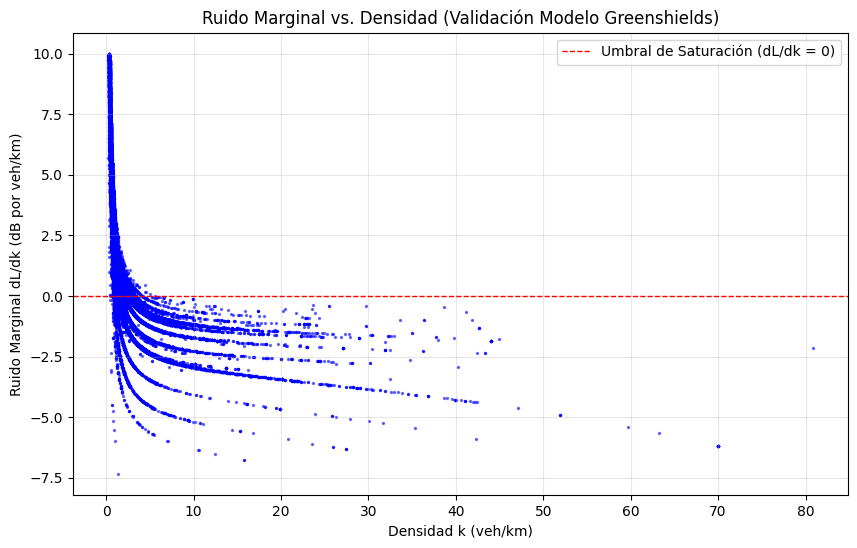

Tramos con Ruido Marginal Negativo (Saturados):


,name,densidad_k,kj,ruido_marginal
1,Gran Via,1.740249,140,-0.676343
7,Topocalma,3.050998,280,-0.687892
8,Topocalma,2.333866,280,-0.245052
9,Clotario Blest Riffo,4.143737,280,-1.071631
12,Pelluhue,7.636155,280,-1.041430


In [4]:
print("6. Calculando Ruido Marginal (dL/dk)...")

def calcular_ruido_marginal(row):
    """
    Implementación de la Ecuación 42 del Documento Técnico.
    Calcula la derivada parcial del Ruido respecto a la Densidad (dL/dk).
    """
    k = row['densidad_k']
    vf = row['velocidad_vf']
    kj = row['kj']
    
    # --- Manejo de Singularidades Matemáticas ---
    
    # 1. Caso k -> 0: El término 10/k tiende a infinito. 
    # Físicamente, agregar el primer auto genera un cambio "infinito" respecto al silencio total.
    # Limitamos k a un mínimo de 0.1 para estabilidad numérica.
    if k < 0.1:
        k = 0.1
        
    # 2. Caso k -> kj: El término 1/(kj-k) tiende a infinito negativo.
    # Esto ocurre en el atasco total. Limitamos para no dividir por cero.
    if k > kj - 1:
        k = kj - 1
        
    # --- Ecuación 42 ---
    term_A = 10 / k
    term_B = (ALPHA_CAI * vf) / (kj - k)
    
    marginal = (1 / np.log(10)) * (term_A - term_B)
    
    return marginal

print(" Calculando Ruido Marginal (dL/dk)")

# Ruido marginal para cada tramo vial
red_vial_final['ruido_marginal'] = red_vial_final.apply(calcular_ruido_marginal, axis=1)

# Scatter plot Ruido Marginal vs Densidad
plt.figure(figsize=(10, 6))
subset = red_vial_final[
    (red_vial_final['densidad_k'] > 0) & 
    (red_vial_final['densidad_k'] < 150) &
    (red_vial_final['ruido_marginal'].between(-10, 10))
]

plt.scatter(subset['densidad_k'], subset['ruido_marginal'], alpha=0.5, s=2, c='blue')
plt.axhline(0, color='red', linestyle='--', linewidth=1, label="Umbral de Saturación (dL/dk = 0)")
plt.title("Ruido Marginal vs. Densidad (Validación Modelo Greenshields)")
plt.xlabel("Densidad k (veh/km)")
plt.ylabel("Ruido Marginal dL/dk (dB por veh/km)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Data RM negativa
print("Tramos con Ruido Marginal Negativo (Saturados):")
display(red_vial_final[red_vial_final['ruido_marginal'] < 0][['name', 'densidad_k', 'kj', 'ruido_marginal']].head())

In [7]:
# Función para promedio ponderado
def promedio_ponderado(df):
    if df['longitud'].sum() == 0: return 0
    return (df['ruido_marginal'] * df['longitud']).sum() / df['longitud'].sum()

#CLASIFICACIÓN (Saturado vs. Sensible)
def clasificar_estado(valor):
    if valor < -0.5: return "Saturado (Reducir flujo puede subir ruido)"
    elif valor > 0.5: return "Sensible (Reducir flujo baja ruido)"
    else: return "Transición / Estable"

#AGREGACIÓN DE RUIDO MARGINAL POR HEXÁGONO
print("1. Agregando Ruido Marginal a los hexágonos")

# Seleccionamos las columnas de interés de la red vial actualizada
cols_vial_marginal = ['ruido_marginal', 'geometry']
# zonas H3 originales
cols_zona = ['h3_9', 'geometry']

# Intersección geométrica
vias_marginales_hex = gpd.overlay(
    red_vial_final[cols_vial_marginal], 
    gdf_zonas[cols_zona], 
    how='intersection'
)
vias_marginales_hex['longitud'] = vias_marginales_hex.length

# Agrupamos por hex
marginal_por_hex = vias_marginales_hex.groupby('h3_9').apply(
    lambda x: pd.Series({'ruido_marginal_promedio': promedio_ponderado(x)})
)

# Unimos con la geo de hex
gdf_diagnostico = gdf_zonas.merge(marginal_por_hex, on='h3_9', how='left')
# nulos con 0 (Neutro)
gdf_diagnostico['ruido_marginal_promedio'] = gdf_diagnostico['ruido_marginal_promedio'].fillna(0)
gdf_diagnostico['Diagnostico'] = gdf_diagnostico['ruido_marginal_promedio'].apply(clasificar_estado)


# MAPA CON BOTONES
print("Generando mapa interactivo multicapa")

#Capa Base (Mapa vacio)
m_final = folium.Map(
    location=[-33.45, -70.65], # Centro aprox de Santiago
    zoom_start=11,
    tiles='CartoDB positron'
)

# Definir el Orden y los Colores
categorias_orden = [
    "Saturado (Reducir flujo puede subir ruido)", 
    "Sensible (Reducir flujo baja ruido)", 
    "Transición / Estable"
]

colores_lista = [
    "black",      # Saturado
    "orange",     # Sensible
    "lightgrey"   # Transición
]

# fuerza a GeoPandas a usar el índice 0 para Saturado, 1 para Sensible, etc.
gdf_diagnostico['Diagnostico'] = pd.Categorical(
    gdf_diagnostico['Diagnostico'], 
    categories=categorias_orden, 
    ordered=True
)

# Generar el Mapa

# Capa 1: Valor Numérico
m_final = gdf_diagnostico.explore(
    m=m_final,
    column='ruido_marginal_promedio',
    cmap='RdYlGn_r', 
    name="Valor Ruido Marginal (dL/dk)",
    legend=True,
    style_kwds={'fillOpacity': 0.7, 'weight': 0.1},
    tooltip=['h3_9', 'ruido_marginal_promedio', 'Diagnostico']
)

# Capa 2: Clasificación Categórica
m_final = gdf_diagnostico.explore(
    m=m_final,
    column='Diagnostico',
    cmap=colores_lista,
    name="Diagnóstico Operativo",
    legend=False,
    style_kwds={'fillOpacity': 0.6, 'weight': 0.1},
    tooltip=['h3_9', 'Diagnostico', 'ruido_marginal_promedio']
)

# Agregar el Control de Capas (Botones)
folium.LayerControl().add_to(m_final)

m_final.save(Path(ruta) / 'data' / 'data_generada' / 'm_ruido_marginal-indicador.html')
print("Mapa guardado como 'm_ruido_marginal-indicador.html' en la carpeta data_generada.")

1. Agregando Ruido Marginal a los hexágonos


/tmp/ipykernel_156311/3312805948.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  marginal_por_hex = vias_marginales_hex.groupby('h3_9').apply(


Generando mapa interactivo multicapa
Mapa guardado como 'm_ruido_marginal-indicador.html' en la carpeta data_generada.
